# <img src="https://img.icons8.com/external-flaticons-lineal-color-flat-icons/64/000000/external-image-analysis-big-data-flaticons-lineal-color-flat-icons-2.png" style="height:50px;display:inline"/> EE 046200 - Technion - Image Processing and Analysis
----

# Computer Homework 3
---
### <span style="color:red"> Due Date: 13.07.25 </span>

## <img src="https://img.icons8.com/clouds/100/000000/upload.png" style="height:50px;display:inline" /> Submission guidelines
---

### READ THIS CAREFULLY

*	**Please notice:** Some of the exercises contain questions on topics that are yet to be taught in the lecture or the frontal exercises. You may consider them as background or preparation questions to the topic before learning about it in class, or you may wait until the topic is taught, and solve only the questions on the topics you already learned.
*	**Avoid unethical behavior.** This includes plagiarism, not giving credit to source code you decide to use, and false reporting of results. Consulting with friends is allowed and even recommended, but you must write the code on your own, independently of others. The staff will treat unethical behavior with the utmost severity. **!אנא המנעו מהתנהגות שאינה אתית והעתקות**
*	Code submission in **Python only**.
    You can choose your working environment:
    * You can work in a Jupyter Notebook , locally with <a href="https://www.anaconda.com/distribution/">Anaconda</a> (the course's computer HW will not require a GPU).
    * You can work in a Python IDE such as <a href="https://www.jetbrains.com/pycharm/">PyCharm</a> or <a href="https://code.visualstudio.com/">Visual Studio Code</a>. Both also allow opening/editing Jupyter Notebooks.
*	The exercise must be submitted **IN PAIRS** (unless the computer homework grader approved differently) until **<span style="color:red"> Thursday 13.07.2025 at 23:55</span>**.
*	The exercise will be submitted via Moodle in the following form:
    You should submit two **separated** files:
    * A report file (visualizations, discussing the results and answering the questions) in a `.pdf` format, with the name `hw3_id1_id2.pdf` where `id1`,`id2` are the ID numbers of the submitting students.
        * Be precise, we expect on point answers. But don't be afraid to explain you statements (actually, we expect you to).
        * Even if the instructions says "Show/Display...", you still need to explain what are you showing and what can be seen.
        * No other file-types ( `.docx` , `.html` , ...) will be accepted
    * A compressed `.zip` file, with the name: `hw3_id1_id2.zip` which contains:
        * A folder named `code` with all the code files inside ( `.py` or `.ipynb` ONLY!)
            *	The code should be reasonably documented, especially in places where non-trivial actions are performed.
            *	Make sure to give a suitable title (informative and accurate) to each image or graph, and also to the axes. Ensure that graphs and images are displayed in a sufficient size to understand their content (and maintain the relationship between the axes - do not distort them).
        * A folder named `my_data`, with all the files required for the code to run (your own images/videos) and all the files you created. make sure to refer to your input files in the code locally. i.e. (if the code is in 'code' directory, and the input file is in a parallel 'my_data' directory):
            `img = cv2.imread('../my_data/my_img.jpg')`
        * **DO NOT** include the given input data in the zip. The code should refer to the given input data as it is located in a folder named `given_data`. i.e.:
            `img = cv2.imread('../given_data/given_img.jpg')`
*	If you submit your solution after the deadline, 4 points will be reduced automatically for each of the days that have passed since the submission date (unless you have approved it with the course staff before the submission date). Late submission will be done directly to the computer homework grader via mail, and not via Moodle.
*	Several Python, numpy, openCV reference files are attached in the Moodle website, and you can of course also use the Internet's help.
*	Questions about the **computer** exercise can be directed to the computer homework grader through the relevant Moodle forum or by email.


## <img src="https://img.icons8.com/bubbles/50/000000/checklist.png" style="height:50px;display:inline"> General Notes:
---

In [1]:
# imports for the HW
import numpy as np
import matplotlib.pyplot as plt
import cv2
import glob
import Q1 as q1

## <img src="https://img.icons8.com/dusk/64/000000/video-trimming.png" style="height:50px;display:inline"/> Part 1 - Sampling and Aliasing in Images
---
In This part we will sample images **in space and in time**, and examine the phenomenon of **aliasing** in both types of sampling. 

In order to do so, we will use the music video of the song Brothers in Arms by Dire Straits. 

Please use the download link available on the course moodle site. Copy the downloaded file to `given_data` folder.

You are encouraged to open the file `Dire Straits - Brothers In Arms.mp4`, to watch the video and appreciate the musical composition.

### 1.a - Spatial Sampling:
1. Sample the last frame from the 50th second of the `Dire Straits - Brothers In Arms.mp4` video and display it. You may use the `video_to_frames` function from your second python HW.

For the spatial sampling in this section we will use a rotated version of this frame, and focus on the region in the frame which contains the neck of the guitar, as seen in the red rectangle in the following figure.

We will focus on counting the string shadows in the red marked area.

![guitar_frame.png](guitar_frame.png)

In [2]:
def video_to_frames(vid_path: str, start_second, end_second):
    """
    Load a video and return its frames from the wanted time range.
    :param vid_path: video file path.
    :param start_second: time of first frame to be taken from the 
                         video in seconds.
    :param end_second: time of last frame to be taken from the 
                         video in seconds.
    :return:
        frame_set: a 4D uint8 np array of size [num_of_frames x H x W x C] 
                   containing the wanted video frames.
    """
    # ====== YOUR CODE: ======
      # Open the video
    cap = cv2.VideoCapture(vid_path)
    
    # Get FPS (frames per second)
    fps = cap.get(cv2.CAP_PROP_FPS)
    
    # Calculate the frame indices for the start and end time
    start_frame = int(start_second * fps)
    end_frame = int(end_second * fps)
    
    # Set the capture to the starting frame
    cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)
    
    # Initialize a list to store the frames
    frame_set = []
    
    # Read frames until the end time is reached
    for frame_idx in range(start_frame, end_frame):
        ret, frame = cap.read()
        if not ret:
            break
        frame_set.append(frame)
    
    # Release the video capture
    cap.release()
    
    # Convert the list to a 4D numpy array: [num_frames, height, width, channels]
    frame_set = np.array(frame_set)
    # ========================
    
    return frame_set



def display_frame(frames,idx):
    # Display first frame
    plt.imshow(cv2.cvtColor(frames[idx], cv2.COLOR_BGR2RGB))  # Convert BGR to RGB for display
    plt.show()


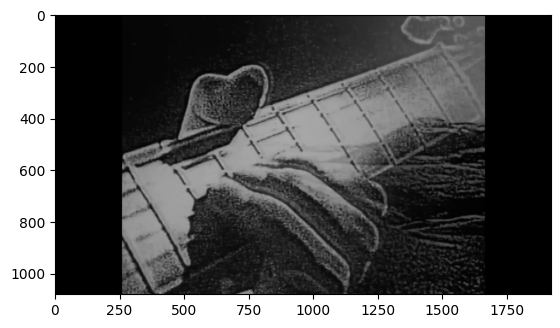

In [3]:
path = '../given_data/Dire Straits - Brothers In Arms.mp4'
frame_set = video_to_frames(path, 50, 51)

display_frame(frame_set,0)

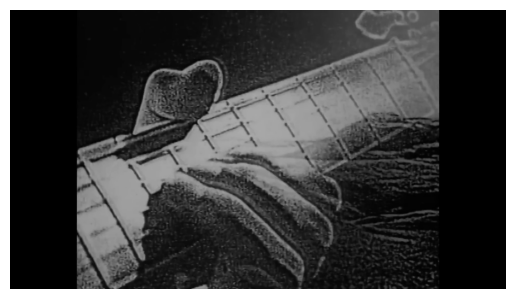

In [4]:
import Q1 as q1
frame = q1.get_frame_at_time(path,50)
q1.display_image(frame)

**Before examining a specific row in the image, we'd like to rotate the image around its center.**

- Use the provided function `rotate` using `cv2.getRotationMatrix2D` and `cv2.warpAffine` to rotate the image.

The function `rotate` returns the rotated image, given the arguments:
1. `image` - the original image to rotate.
2. `angle` - the rotation angle (degrees).

In [5]:
##### Given code
def rotate(image, angle):
    image_center = tuple(np.array(image.shape[1::-1]) / 2)
    rot_mat = cv2.getRotationMatrix2D(image_center, angle, 1.0)
    result = cv2.warpAffine(image, rot_mat, image.shape[1::-1], 
                            flags=cv2.INTER_LINEAR)
    return result

**From now on, work with the rotated image.**

- Display the rotated image, using `angle` value in the interval $[-20, -30]$. 
- Choose a value that places the guitar neck horizontally. 

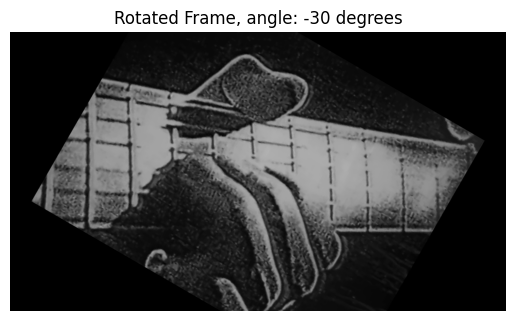

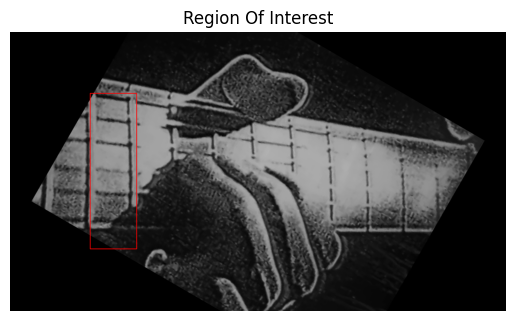

In [6]:

angle = -30

frame = rotate(frame_set[-1],angle)
q1.display_image(frame,title=f"Rotated Frame, angle: {angle} degrees")


#roi: 
h, w, c = frame.shape
col = 400
row = h // 2
dr =300
dc = 90

q1.display_image(q1.draw_roi(frame,row,col,dr,dc),"Region Of Interest")

**2. Let us examine the `400`th column of the image.**

Create a copy of the rotated image in which this column is marked in red and display it.

In addition, create and display a graph containing the gray levels of the `400`th column of one of the color channels (your choice) as a function of the row index.

  <div class="alert alert-block alert-warning">
<b>Question:</b>
    How many shadows can you identify from the gray level profile?
</div>

  <div class="alert alert-block alert-info">
  <strong> Answer: </strong> I can recognize 6 shaddow stripes, and count ~5 shadow dips in the graph below
</div>


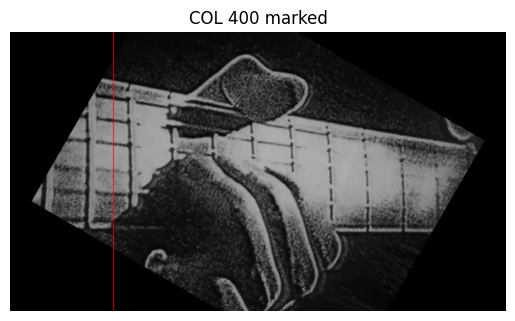

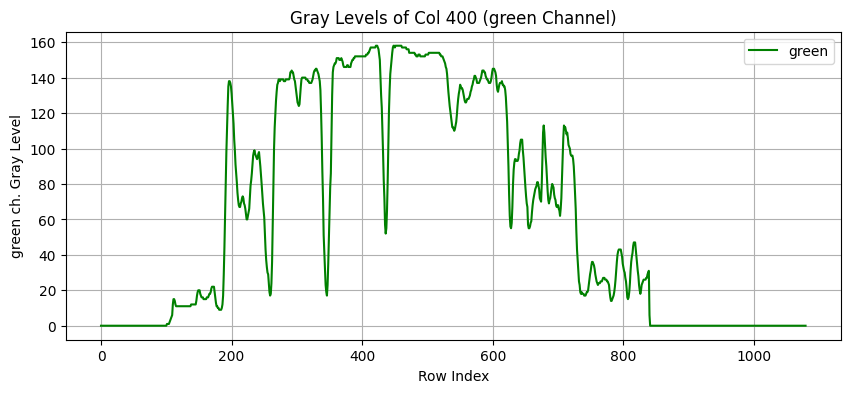

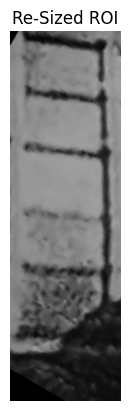

In [7]:
q1.examine_col(frame,400)
q1.plot_col_grey_levels_by_channel(frame,1,col_idx=400)
q1.display_roi(frame, row, col, dr, dc)


**3 . Now, for the spatial sampling:** sample the image with sampling interval of $\Delta y=58$ (meaning - sample only the rows of the image, with no sampling on the $x$-axis).

The sampling will start at the middle of the image (the green line in the above figure) and continue towards both directions (i.e., the central row of the image is sampled, and then all the rows in the image that are of $n\cdot\Delta y$ distance from it, for $n\in\mathbb{Z}$ (within image borders, of course)). 

Display the sampled image and a copy of the original image in which the sampled rows are marked in red.

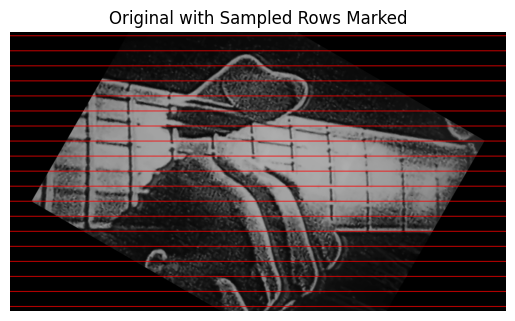

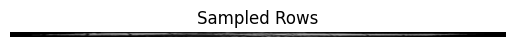

In [8]:
sampled_img, sampled_rows = q1.spatial_sample_rows(frame,58)
q1.display_image(sampled_img, "Sampled Rows")

**4. In order to evaluate the result of sampling we would like to return the image to its original dimensions.**

We will do so by interpolating on the row dimension, using `cv2.resize` that uses bilinear interpolation by default. Return the sampled image to its original dimensions and display the result.

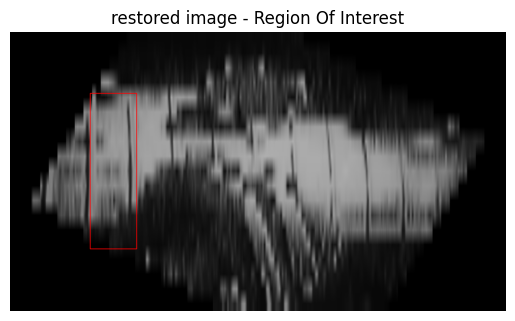

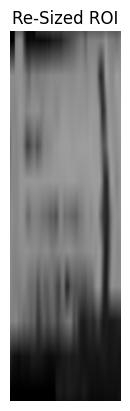

In [9]:
restored_img = q1.interpolate_to_original_height(sampled_img, frame.shape[0])
# q1.display_image(restored_img,"restored image")
q1.display_image(q1.draw_roi(restored_img,row,col,dr,dc),"restored image - Region Of Interest")

q1.display_roi(restored_img, row, col, dr, dc)


**5. Examine our region of interest (the red rectangle in section 1.a.1) in your new image.**

How many string shadows can you identify? What's causing this effect?

Create and display a graph containing the gray levels of the `400`th column in one of the color channel you previously chose as a function of the row index for the interpolated image.

  <div class="alert alert-block alert-warning">
<b>Question:</b>
    What are the differences between this graph and the graph from section 1.a.2? Explain.
</div>

  <div class="alert alert-block alert-info">
  <strong> Answer: </strong>the dips in the graph are a lot wider, indicating smudges and not distinct shapes. 
</div>


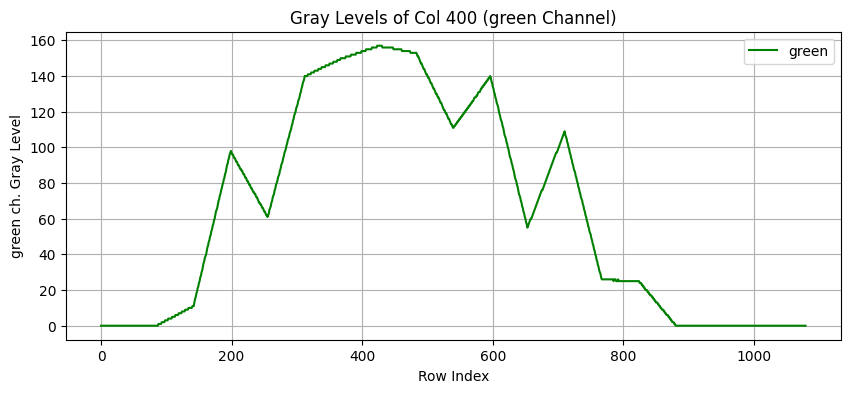

In [10]:
q1.plot_col_grey_levels_by_channel(restored_img,1,col_idx=400)

### 1.b - Temporal Sampling:
**1. In this part we would like to perform a temporal sample on a time section from the video.**
- Watch the time section between the seconds `10-20`.
- In this part we will use only this time section. 
- You may use the `video_to_frames` function from your last python HW.


<div class="alert alert-block alert-warning">
    <b>Question:</b>
       What is the frequency of the pendulum?
    </div>

**Answer**: 
- The pendalum has 3.5 cycles in 10 seconds so its freq is 3.5Hz.
 $$ T_{period} =\frac{time}{cycles}= \frac{10}{3.5} \Longrightarrow  f = \frac{cycles}{time} = \frac{3.5}{10} = 3.5Hz    $$



In [11]:
# Load frames from the video between 30-45 seconds
frames = q1.video_to_frames(path, start_time=10, duration=20)


**2. Sample the time section with sampling interval of $\Delta p=37$** (meaning - the frames indexed 0, 37, 74, etc...). 

 - In order to examine the influence of the temporal sampling, create a new video having the duration of the original time section (10 seconds) and the same FPS rate.
 - In order to do so, use Zero-Order Hold interpolation: every frame in your sampled video will be translated in the new video into $\Delta p=37$ consecutive frames. 
- Create the video and save it in `mp4` format. **Attach the video to your submission in the my_data folder**. (Note that the video does not need to contain sound).

In [38]:
# Create the temporal sampled video
output_video_path = "../my_data/temporal_sampled_video.mp4"
q1.create_temporal_sampled_video(frames, output_video_path,fps=25, sample_interval=250)
print(f"Temporal sampled video saved to {output_video_path}")

Temporal sampled video saved to ../my_data/temporal_sampled_video.mp4


**3 . Watch the video you created** 

  <div class="alert alert-block alert-warning">
<b>Question:</b>
    What is the difference comparing to the original video? 
</div>

**Answer:** The main differences between the videos is 
- our video is not continues.
- It shows single frames, hinting at the motion of the pendalum.
- the result shows the pendalum at oposite side each time  
    
<div class="alert alert-block alert-warning">
<b>Question:</b>
    What is the minimal $\Delta p$ to choose, if the desired result is a video with the pendulum staying in its place?
</div>



**Answer:**
- The number of frames extracted between 10 and 20 seconds is 251. that ia the minimal $\Delta{P}$ to choose.
- This way we only sample the first frame and so the motion seems frozen. This is called aliasing.  
- The reason is that since the pendalum is hand drawn and its motion adapted to the song, the result is not precise.
   So any attempt at finding a sampeling rate intended at sampling the same phase causing aliasing was unsucessfull. 
- in the first version of the assignment (wich i did before reuploading, we saw clocks mooving inwords/outwards on screen.
- When sampling at the apropreate $\Delta{P}$ the clocks chainged direction. 

## <img src="https://img.icons8.com/external-flaticons-lineal-color-flat-icons/64/000000/external-scatter-infographic-flaticons-lineal-color-flat-icons-3.png" style="height:50px;display:inline"/> Part 2 - PCA Compression
---
One of the ways to compress images is by using dimensionality reduction and saving the image representaion in the lower dimension. One of the classic methods for dimensionality reduction is Principal Component Analysis (PCA).

In This part we will examine this method and its performance on a set of images containing faces of people: Labelled Face In the Wild (LFW). The set consists of `13233` gray-scale images of size `64x64`.

* **Note:** You ar not allowed to use PCA functions already implemented in Python packages in this part.

In [13]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt

def load_lfw_images(folder_path, image_size=(64, 64)):
    """
    Loads all grayscale images from a folder into a 3D numpy array.
    :param folder_path: path to the folder containing images
    :param image_size: tuple (H, W)
    :return: numpy array of shape [H, W, N]
    """
    image_files = sorted([f for f in os.listdir(folder_path) if f.endswith(('.jpg', '.png', '.pgm'))])
    H, W = image_size
    N = len(image_files)
    images = np.zeros((H, W, N), dtype=np.uint8)

    for i, fname in enumerate(image_files):
        img = cv2.imread(os.path.join(folder_path, fname), cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (W, H))  # Resize in case
        images[:, :, i] = img

    return images, image_files

def display_sample_images(images, indices):
    """
    Displays sample grayscale images from a 3D array.
    :param images: numpy array of shape [H, W, N]
    :param indices: list of indices to display
    """
    fig, axes = plt.subplots(1, len(indices), figsize=(12, 3))
    for ax, idx in zip(axes, indices):
        ax.imshow(images[:, :, idx], cmap='gray')
        ax.set_title(f"Index: {idx}")
        ax.axis('off')
    plt.tight_layout()
    plt.show()

def reshape_images_to_matrix(images):
    """
    Reshapes a 3D array of images to a 2D matrix X [4096, N]
    :param images: numpy array of shape [H, W, N]
    :return: matrix X
    """
    H, W, N = images.shape
    X = np.zeros((H * W, N))
    for i in range(N):
        X[:, i] = np.reshape(images[:, :, i], (H * W,), order='F')
    return X

def compute_mean_and_center(X):
    """
    Computes the mean image and centers the data.
    :param X: matrix of shape [4096, N]
    :return: mu [4096,1], Y [4096, N]
    """
    mu = np.mean(X, axis=1, keepdims=True)
    Y = X - mu
    return mu, Y

def display_image_vector_as_image(vec, shape=(64, 64), title=""):
    """
    Displays a single vector reshaped to image.
    """
    img = np.reshape(vec, shape, order='F')
    plt.imshow(img, cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()

def compute_covariance_matrix(Y):
    """
    Computes the covariance matrix of Y.
    """
    return np.cov(Y)


### 2.a - Pre-processing & covariance matrix
1. Uncompress the dataset in a sub-folder named `LFW` in the `given_data` folder. Load all of the images into a 3D numpy array of size `64x64x13233` (after converting them to grayscale). Display 4 images from the data set (remember their indices - these are the images you will restore later in the exercise).
    * **Note: DO NOT upload the data set as part of your submission!**


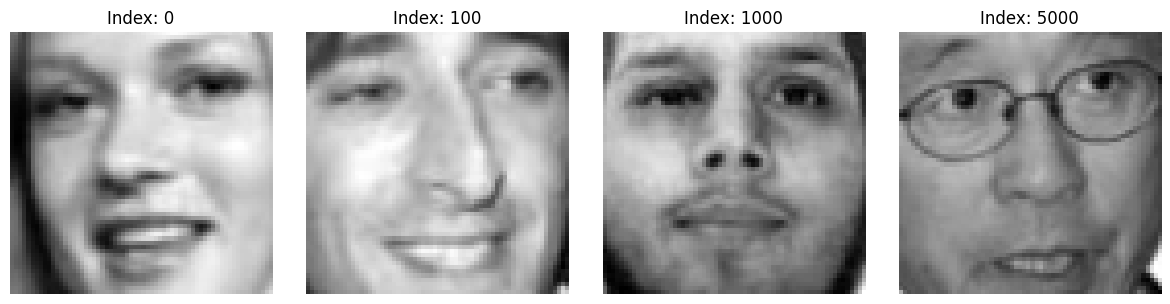

In [14]:
lfw_images, filenames = load_lfw_images(folder_path="../given_data/LFW/")
selected_indices = [0, 100, 1000, 5000]  # Remember these for later
display_sample_images(lfw_images, selected_indices)


2. Define numpy array `X` of size `4096x13233` in which every column represents one of the images in column-major representation (don't forget the `'F'` argument in `np.reshape`). 


In [15]:
X = reshape_images_to_matrix(lfw_images)

3. Calculate the mean of every pixel in the `X` array (results in a `4096` vector) and display it as a `64x64` image (don't forget the `'F'` argument in `np.reshape`). Now, transform the mean vector into a `4096x1` array and call it `mu`. Subtract `mu` from `X` to get an array of data centered around 0 - call it `Y`. 

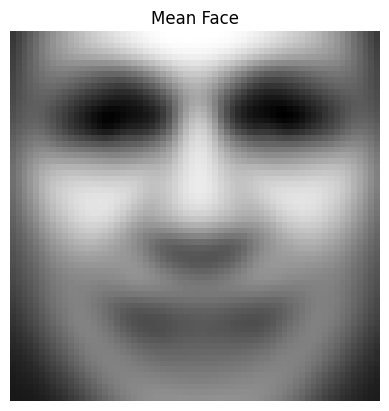

In [16]:
mu, Y = compute_mean_and_center(X)
display_image_vector_as_image(mu, title="Mean Face")



4. Calculate the covariance matrix of `Y` using `np.cov`. Note that the size of the covariance matrix is depended on the size of each sample, and in our case we should get a matrix of size `4096x4096`.

In [17]:
cov = compute_covariance_matrix(Y)
print("Shape of Covariance Matrix:", cov.shape)


Shape of Covariance Matrix: (4096, 4096)


### 2.b - Principal Components
The eigenvectors of the covariance matrix are called the **Principal Components**. If one would calculate all of the principal components of our covariance matrix, they will get a spanning set of the $\mathbb{R}^{4096}$ space. In practice, in order to perform dimensionality reduction, we want to project our data into a lower dimension. In PCA we do so by projecting every image into a space with a spanning set of $k$ eigenvectors (principal components) corresponding to the $k$ largest eigenvalues of the covariance matrix.


In [18]:
def compute_principal_components(cov_matrix, k=10):
    # Compute the eigenvalues and eigenvectors using np.linalg.eigh
    eig_vals, eig_vecs = np.linalg.eigh(cov_matrix)
    
    # Sort eigenvalues and eigenvectors in descending order (largest first)
    sorted_indices = np.argsort(eig_vals)[::-1]
    eig_vals_sorted = eig_vals[sorted_indices]
    eig_vecs_sorted = eig_vecs[:, sorted_indices]
    
    # Get the top k eigenvalues and eigenvectors
    eig_vals_k = eig_vals_sorted[:k]
    eig_vecs_k = eig_vecs_sorted[:, :k]
    
    return eig_vals_k, eig_vecs_k

def display_image_vector_as_image(vector, title=""):
    """
    This function reshapes a flattened vector into a 64x64 image and displays it.
    The 'F' argument ensures the reshape happens in Fortran-style (column-major) order.
    """
    image = vector.reshape((64, 64), order='F')  # Using 'F' for column-major order
    plt.imshow(image, cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()

def display_eigenvalues_and_components(eig_vals, eig_vecs, num_components=4):
    # Plot the eigenvalues
    plt.plot(eig_vals, marker='o')
    plt.title('Eigenvalues')
    plt.xlabel('Index')
    plt.ylabel('Eigenvalue')
    plt.grid(True)
    plt.show()
    
    # Display the first few principal components as images
    for i in range(num_components):
        component = eig_vecs[:, i]
        display_image_vector_as_image(component, title=f"Principal Component {i+1}")

# === Execution ===




Calculate the `k=10` largest eigenvalues of the covariance matrix and their corresponding principal components. 
* The parameter `eig_vals` will contain the `k=10` eigenvalues in descending order (largest eigenvalue first).
* The parameter `eig_vecs` will contain a matrix in which the columns are the corresponding principal components in order respective to `eig_vals`. 
* The covariance matrix is symmetric, so you can use `np.linalg.eigh` in order to find them. 

In [19]:
# === Execution ===
eig_vals_k, eig_vecs_k = compute_principal_components(cov, k=10)
print("Eigenvalues:", eig_vals_k)


Eigenvalues: [2066495.07260607  924622.67171717  449317.23865336  268536.2804806
  238254.34235513  150607.83658686  137387.43896977  122783.12342939
  108041.71161005  102054.45968042]


Display a plot of the `eig_vals` vector. In addition, display the first 4 principal components in `eig_vecs` as images of size `64x64` (don't forget the `'F'` argument in `np.reshape`).

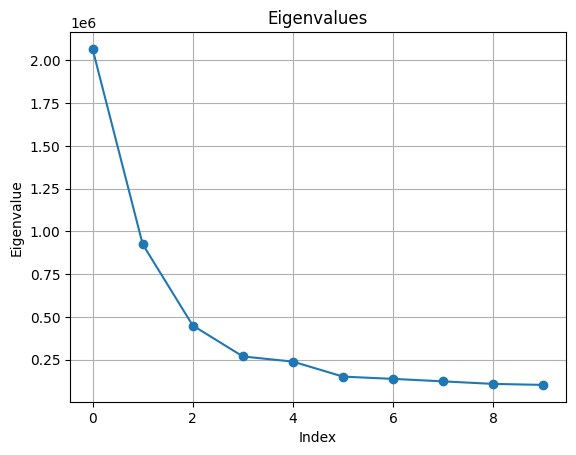

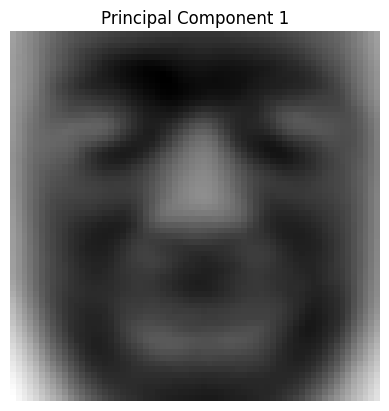

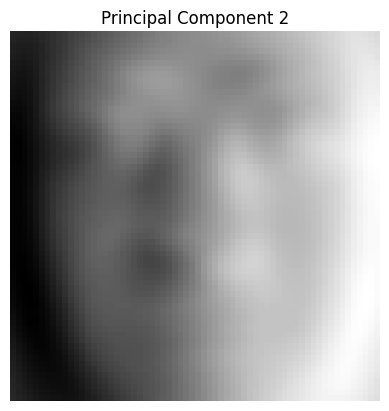

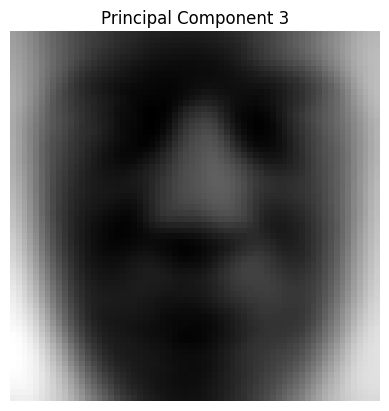

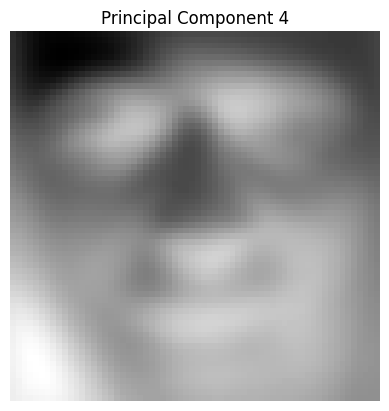

In [20]:
display_eigenvalues_and_components(eig_vals_k, eig_vecs_k)

### 2.c - Compression by projection
Find the projection of every image in the space spanned by the `k=10` principal components by calculating:
$$ P = V^T Y $$
where $V$ is the `eig_vecs` matrix and $Y$ is the data matrix `Y`.

Note that now each column of the matrix $P$ is actually a representation of one image from the data set (after subtracting the mean), in the lower dimension.

In [21]:
def compress_images_by_projection(Y, eig_vecs, k=10):
    """
    Project the centered data Y into the subspace spanned by the top k principal components.
    :param Y: The centered data matrix of size [4096 x num_images]
    :param eig_vecs: The eigenvectors matrix containing the top k principal components of size [4096 x k]
    :param k: The number of principal components to use for the projection
    :return: The compressed representation of the images in the reduced k-dimensional space.
    """
    # Perform the projection: P = V^T Y
    P = np.dot(eig_vecs[:, :k].T, Y)
    return P


In [22]:
# === Execution ===
P_compressed = compress_images_by_projection(Y, eig_vecs_k, k=10)
print("Compressed data shape:", P_compressed.shape)

Compressed data shape: (10, 13233)


### 2.d - Restoration
For the 4 images you presented in section 2.a.1, extract the appropriate columns in the $P$ matrix. We will denote each column as $p_i$ where $i\in \{1,2,3,4\}$. Find $\hat{x}_i$, the restoration of each column by applying:
$$\hat{x}_i=Vp_i+\mu$$
Where $\mu$ is the calculated mean `mu`. Display the 4 restored images (sized `64x64`). In the title of each image display the MSE between the original image and the restoration. Reminder:
$$MSE_i=\frac{1}{MN}\sum_{m=0}^{M-1}\sum_{n=0}^{N-1}(x_i[m,n]-\hat{x}_i[m,n])^2$$
Where $x_i$ is the original image corresponding to column $p_i$ in $X$.

In [23]:
import numpy as np

def restore_images(P, eig_vecs, mu, selected_indices, k=10):
    """
    Restore images from their projection in the lower-dimensional space.
    :param P: The compressed data matrix of size [k x num_images]
    :param eig_vecs: The eigenvectors matrix of size [4096 x k]
    :param mu: The mean vector to add back after restoring (should be of size [4096, 1])
    :param selected_indices: Indices of the images to restore
    :param k: Number of principal components used
    :return: Restored images as 64x64 numpy arrays and MSE values
    """
    restored_images = []
    mse_values = []

    # Ensure mu is a column vector (shape [4096, 1])
    mu = mu.reshape(-1, 1)

    for idx in selected_indices:
        p_i = P[:, idx]  # Get the compressed vector for image i

        # Project back to the original space using the eigenvectors
        x_hat_i = np.dot(eig_vecs[:, :k], p_i)

        # Add the mean back to the restored image (reshape to [4096, 1] for broadcasting)
        x_hat_i += mu.flatten()  # Flatten mu to make sure the addition works

        # Reshape to 64x64 image
        restored_image = x_hat_i.reshape(64, 64)
        restored_image = np.rot90(restored_image,k=-1)

        # Calculate the MSE between the original and restored images
        x_i = X[:, idx].reshape(64, 64)  # Get the original image
        mse = np.mean((restored_image - x_i) ** 2)

        restored_images.append(restored_image)
        mse_values.append(mse)

    return restored_images, mse_values

def display_restored(restored_images, mse_values, selected_indices, K="10"):
    # Display the restored images and their MSE
    fig, axes = plt.subplots(1, 4, figsize=(15, 3))
    for ax, restored_image, mse, idx in zip(axes, restored_images, mse_values, selected_indices):
        ax.imshow(restored_image, cmap='gray')
        ax.set_title(f"MSE: {mse:.4f} - Index {idx}, K="+ K)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

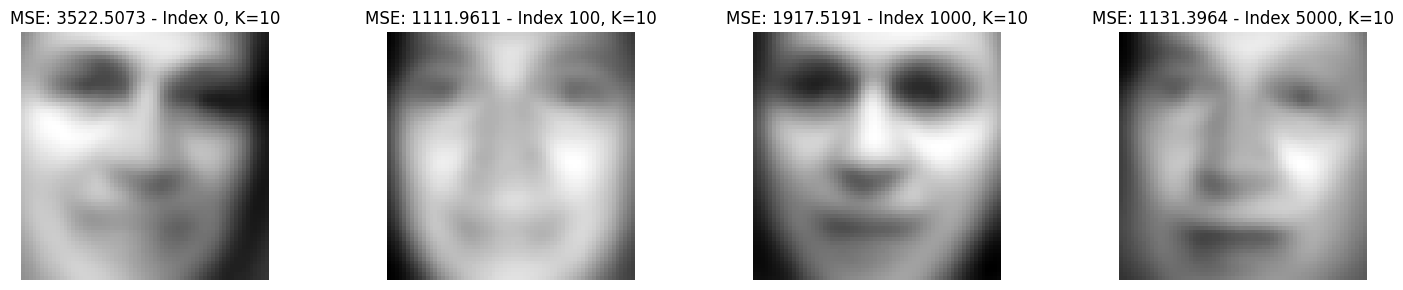

In [24]:

# === Execution ===
selected_indices = [0, 100, 1000, 5000]  # Remember the indices from part 2.a
restored_images, mse_values = restore_images(P_compressed, eig_vecs_k, mu, selected_indices, k=10)
display_restored(restored_images, mse_values, selected_indices)


### 2.e - Changing $k$ value
Now, compress `Y` using `k=570` principal components, and restore and display again the 4 images you chose. What do you think of the restored results now? Compare to the `k=10` case. Note that although we have enlarged the dimension of the images in the low dimesional space, it is still less than 7 times (!) smaller than the original image.

Compressed data shape: (570, 13233)


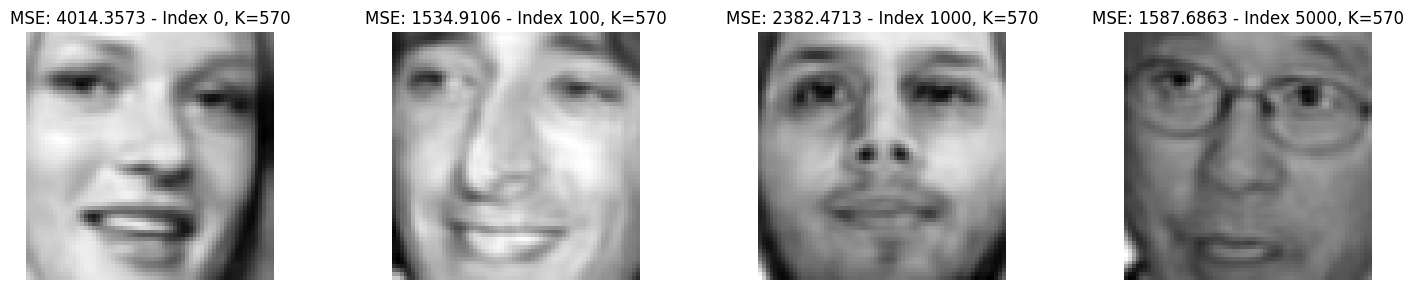

In [25]:
eig_vals_k, eig_vecs_k = compute_principal_components(cov, k=570)
P_compressed = compress_images_by_projection(Y, eig_vecs_k, k=570)
print("Compressed data shape:", P_compressed.shape)

selected_indices = [0, 100, 1000, 5000]  # Remember the indices from part 2.a
restored_images, mse_values = restore_images(P_compressed, eig_vecs_k, mu, selected_indices, k=570)
display_restored(restored_images, mse_values, selected_indices,K="570")


### PCA Compression with k = 570

After compressing the centered data matrix \( Y \) using \( k = 570 \) principal components, we restore and display the same 4 selected images.

#### Observations:
- The reconstructed images are significantly sharper and preserve much more detail compared to the \( k = 10 \) case.
- Facial features are clearly recognizable, and the images appear visually close to the originals.
- The Mean Squared Error (MSE) is substantially lower, indicating a more accurate reconstruction.

#### Compression Efficiency:
- Each image is now represented by only 570 values instead of 4096.
- This results in a compression factor of approximately 7× while maintaining high visual quality.

#### Conclusion:
This result demonstrates the strength of PCA — most of the meaningful variance in the dataset can be captured by a relatively small number of components. Increasing \( k \) leads to better reconstruction, but with diminishing returns after a certain point.


## <img src="https://img.icons8.com/external-others-pike-picture/50/000000/external-comparison-recognition-others-pike-picture.png" style="height:50px;display:inline"/> Part 3 - Image Restoration
---
In this part we aim to restore an image from its noisy version. In class, you learned about image restoration as solutions to optimization problems. This field views images from a probabilistic standpoint to restore blurred or noisy images.

During this part we will use the movie trailer of Flash Gordon. Feel free to open the file `Flash Gordon Trailer.mp4`, to watch the video and enjoy the great music by Queen. :)

For this task, we'll test two different restoration algorithms. However, to do so, we need to create a noisy version of a given image first.

### 3.a - Pre-processing - Creating a noisy image
- Load one frame from the video `Flash Gordon Trailer.mp4`. The frame must be taken from the time section `00:20-00:21`. The python workshop document can help with this task.
- Display this frame as a color image.
- Choose **one** of the color channels out of the chosen frame: the **red** channel or the **green** channel. Display the grayscale image of the chosen channel. 
- Decrease the size of the image by a factor of 2 using `cv2.resize`. From now on we will use only this channel (after the resize) as our original image.
* Implement the `poisson_noisy_image` function, defined below, by following this procedure:<br>
  Let $a$ be the number of photons that have to arrive into the camera in order to be translated into one gray level. Now, we will create our Poisson noisy image (a.k.a shot noise) in a way which simulates realistic noise induced in an image taken by an optical camera (photon counting):
    1. transform the type of `X`, the input image, to `float` (the values of the image should still be in the range of `[0,255]`, just represented as `float` istead of `uint8`) and multiply the gray level values by $a$ in order to transform the image to number of photons units.
    2. Create a new Poisson noisy image by applying `np.random.poisson` on your image. Using this command, the value of every pixel in the input (number of photons) is referred to as the mean of a Poisson-distributed random variable.
    3. Divide the resulting image by $a$ in order to return the image to normal gray levels.
    4. Clip the image to `[0,255]` using `np.clip`, and transform the image type back to `uint8`.
    5. The noisy image you got will be the image $Y$.
* Make a noisy image out of the resized grayscale image using the `poisson_noisy_image` function with `a=3`.
* Display the noisy image result.


In [26]:
def poisson_noisy_image(X, a):
    """
    Creates a Poisson noisy image.
    :param X: The Original image. np array of size [H x W] and of type uint8.
    :param a: number of photons scalar factor
    :return:
        Y: The noisy image. np array of size [H x W] and of type uint8.
    """
    X = X.astype(float)                  # Convert to float
    photons = X * a                      # Convert gray levels to photon counts
    noisy_photons = np.random.poisson(photons)  # Apply Poisson noise
    Y = noisy_photons / a                # Convert back to gray levels
    Y = np.clip(Y, 0, 255)               # Clip to valid range
    Y = Y.astype(np.uint8)               # Convert back to uint8
    
    return Y


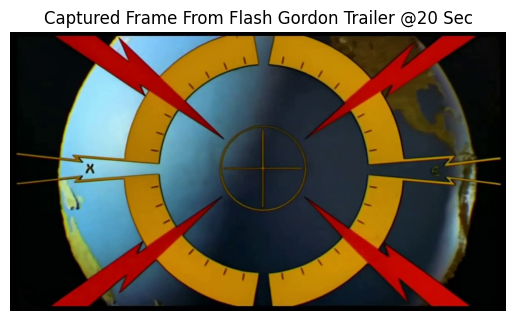

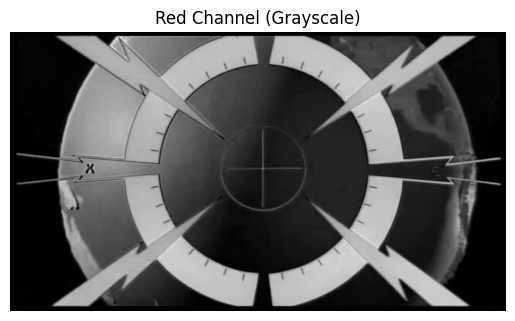

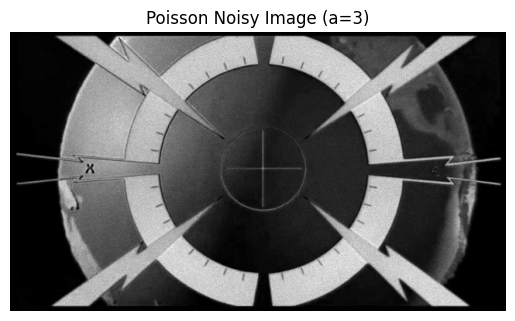

In [27]:
path_q3 = '../given_data/Flash Gordon Trailer.mp4'

#capturing a frame from the flash gordon trailer
frame_q3 = q1.get_frame_at_time(path_q3,20.5)

# displaying the captured frame
q1.display_image(frame_q3, f"Captured Frame From Flash Gordon Trailer @20 Sec")
    
# displaying grayscale of the red channel
q1.show_color_channel_in_grey_scale(frame_q3,0)
    
# #decreasing image's size by 2
red_channel = frame_q3[:, :, 0]
resized_red = cv2.resize(red_channel, (red_channel.shape[1] // 2, red_channel.shape[0] // 2))

# displaying the poisson noisy image's result
noisy = poisson_noisy_image(resized_red, a=3)
q1.display_image(noisy ,"Poisson Noisy Image (a=3)",grey=1)



### 3.b - Denoise by L2
Let $Y$ be a noisy image version of the image $X$. In order to restore $X$ out of $Y$ we would would to minimize the following expression (cost function):
$$\varepsilon^2\{\underline{X}\}=(\underline{X}-\underline{Y})^T(\underline{X}-\underline{Y})+\lambda(D\underline{X})^T(D\underline{X})$$

Where $\underline{X}$ is a column-stack vector of the image $X$, $\underline{Y}$ is a column-stack vector of the noisy image $Y$, $\lambda$ is the regularization parameter, and $D$ is a sparse matix of the Laplacian operator, given by the kernel:
$$D_{kernel}=\begin{bmatrix}
0 & 1 & 0\\
1 & -4 & 1\\
0 & 1 & 0
\end{bmatrix}$$

In order to restore the source image we will apply an iterative process, based on the Steepest Descent algorithm. The update step of the algorithm is:
$$\underline{\hat{X}}_{k+1} = \underline{\hat{X}}_{k}-\mu_k\underline{G}_k = \underline{\hat{X}}_{k}-\mu_k((I+\lambda D^TD)\underline{\hat{X}}_{k}-\underline{Y})$$
Where $I$ is the identity matrix and $\mu_k$ is the step size, which is determined by:
$$\mu_k = \frac{\underline{G}_k^T\underline{G}_k}{\underline{G}_k^T(I+\lambda D^TD)\underline{G}_k}$$
The process is initialized with $\underline{\hat{X}}_{0}=\underline{Y}$.

Implement the algorithm described above in the following function, where `Err1,2` are defined as follows:
$$
Err1\{\underline{\hat{X}}_{k}\}=(\underline{\hat{X}}_{k}-\underline{Y})^T(\underline{\hat{X}}_{k}-\underline{Y})+\lambda (D\underline{\hat{X}}_{k})^T(D\underline{\hat{X}}_{k})
$$
$$
Err2\{\underline{\hat{X}}_{k}\}=(\underline{\hat{X}}_{k}-\underline{X})^T(\underline{\hat{X}}_{k}-\underline{X})
$$

In [28]:
import numpy as np
from scipy.signal import convolve2d

def denoise_by_l2(Y, X, num_iter, lambda_reg):
    """
    L2 image denoising using steepest descent.
    :param Y: The noisy image. np array of size [H x W]
    :param X: The Original image. np array of size [H x W]
    :param num_iter: the number of iterations for the algorithm perform
    :param lambda_reg: the regularization parameter
    :return:
    Xout: The restored image. np array of size [H x W]
    Err1: The error between Xk at every iteration and Y.
    np array of size [num_iter]
    Err2: The error between Xk at every iteration and X.
    np array of size [num_iter]
    """
   
    # ====== YOUR CODE: ======
    h, w = Y.shape
    y_vec = Y.flatten(order='F')  # column vector
    xk = y_vec.copy()

    Err1 = np.zeros(num_iter)
    Err2 = np.zeros(num_iter)

    # Laplacian kernel
    D_kernel = np.array([[0, 1, 0],
                         [1, -4, 1],
                         [0, 1, 0]])

    for k in range(num_iter):
        # Compute gradient Gk
        xk_mat = np.reshape(xk, (h, w), order='F')
        Dx = cv2.filter2D(xk_mat, -1, D_kernel, borderType=cv2.BORDER_REFLECT)
        DTDx = cv2.filter2D(Dx, -1, D_kernel, borderType=cv2.BORDER_REFLECT)
        grad = (xk - y_vec) + lambda_reg * DTDx.flatten(order='F')

        # Step size mu_k
        grad_mat = np.reshape(grad, (h, w), order='F')
        Dg = cv2.filter2D(grad_mat, -1, D_kernel, borderType=cv2.BORDER_REFLECT)
        DTDg = cv2.filter2D(Dg, -1, D_kernel, borderType=cv2.BORDER_REFLECT)
        DTDg_vec = DTDg.flatten(order='F')

        numerator = np.sum(grad ** 2)
        denominator = np.sum(grad * (grad + lambda_reg * DTDg_vec)) + 1e-8
        mu_k = numerator / denominator

        # Update
        xk = xk - mu_k * grad

        # Errors
        xk_mat = np.reshape(xk, (h, w), order='F')
        Dxk = cv2.filter2D(xk_mat, -1, D_kernel, borderType=cv2.BORDER_REFLECT)
        Err1[k] = np.sum((xk - y_vec) ** 2) + lambda_reg * np.sum(Dxk ** 2)
        Err2[k] = np.sum((xk - X.flatten(order='F')) ** 2)

    Xout = np.reshape(xk, (h, w), order='F')
    Xout = np.clip(Xout, 0, 255).astype(np.uint8)

    return Xout, Err1, Err2
    # ========================
    


Note that your algorithm uses the original image `X` only to calculate `Err2`, you sould not use it anywhere else in the algorithm!

**Guidance**: Note that your inputs `Y,X` and your output `Xout` are image matrices (2d numpy arrays), but $\underline{Y},\underline{\hat{X}}, \underline{\hat{X}}_k$ are column-major order vectors. Use `npmatrix.flatten('F')` to create a column-order vector out of `npmatrix`. In addition, it is recommended to calculate the multlipication with $D$ using convolution with the kernel, and **not** calculating the full Toeplitz matrix. Note that every time you encounter a multlipication with $D$ in your calculation you must:
1. Transform the column vector into a matrix, using column-major order (`np.reshape(vector, newshape, order='F')`).
2. Convolve the matrix with the kernel using `cv2.filter2D` (note that the result has the same size as the input - 'same' convolution, and again - $D_{kernel}$ is symmetric so it doesn't matter that `cv2.filter2D` performs correlation and not convolution).
3. Transform the resulting matrix back to a cloumn vector.
* Notice that for example the $\lambda D^T D \underline{\hat{X}}$ part requires you to do the above process twice.

Now, use the function you wrote on the noisy image you created in section 3.a. use `lambda_reg = 0.5` and `num_iters = 50`. Display the result of the restoration in your report.

In addition, display **on a single graph** a logarithmic plot of the errors `Err1` and `Err2` as a function of the iteration number, and explain.

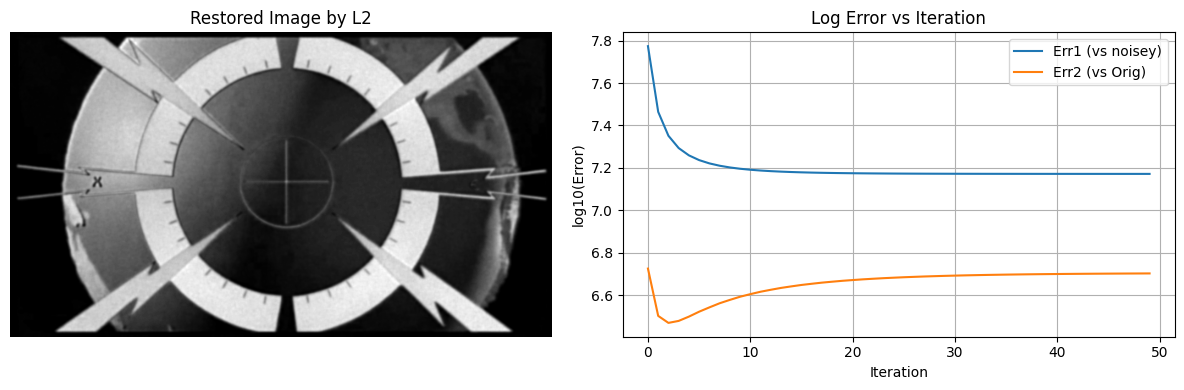

In [29]:
# ====== YOUR CODE: ======
# Parameters 
lambda_reg = 0.5
num_iter = 50


def display_denoising(Xrestored, Err1, Err2, title="", label1='Err1 (vs noisey)', label2='Err2 (vs Orig)'):
    # Display
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.title(title)
    plt.imshow(Xrestored, cmap='gray')
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.title("Log Error vs Iteration")
    plt.plot(np.log10(Err1), label = label1)
    plt.plot(np.log10(Err2), label = label2)
    plt.xlabel('Iteration')
    plt.ylabel('log10(Error)')
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()
# ========================
# Run algorithm
Xrestored, Err1, Err2 = denoise_by_l2(noisy, resized_red, num_iter=50, lambda_reg=0.5)
display_denoising(Xrestored, Err1, Err2, title="Restored Image by L2")


### 3.c - Denoise by Total Variation
Now you will implement a restoration using a Total Variation prior. Meaning, you will work with the following cost function:
$$\varepsilon^2\{\underline{X}\}=(\underline{X}-\underline{Y})^T(\underline{X}-\underline{Y})+\lambda\cdot TV\{\underline{X}\}$$
Where $TV\{X\}$ is the Total Variation function:
$$ TV\{X\}=\sum_{x,y}|\nabla X|=\sum_{x,y}\sqrt{\left(\frac{\partial X}{\partial x}\right)^2+\left(\frac{\partial X}{\partial y}\right)^2}$$
Where $x,y$ are the 2D axes of the image.
In order to perform restoration, we will again use an iterative process as in section 3.b, but now we will apply a gradient step appropriate to TV:
$$\hat{X}_{k+1} = \hat{X}_{k}+\frac{\mu_k}{2}U_k = \hat{X}_{k}+\frac{\mu_k}{2}\left(2\left(Y-\hat{X}_{k}\right)+\lambda\nabla\cdot\left(\frac{\nabla\hat{X}_{k}}{\sqrt{|\nabla\hat{X}_{k}|^2+\epsilon_0^2}}\right)\right)$$
Note that there are no underlines in the above equation - here we use the images' matrices.

Implement this algorithm in the following function, where `Err1` is now defined as:
$$
Err1\{\underline{\hat{X}}_{k}\}=(\underline{\hat{X}}_{k}-\underline{Y})^T(\underline{\hat{X}}_{k}-\underline{Y})+\lambda\cdot TV\{\underline{\hat{X}}_{k}\}
$$ 

In [30]:
def denoise_by_TV(Y, X, num_iter, lambda_reg, epsilon0):
    """
    TV image denoising.
    :param Y: The noisy image. np array of size [H x W]
    :param X: The Original image. np array of size [H x W]
    :param num_iter: the number of iterations for the algorithm perform
    :param lambda_reg: the regularization parameter
    :param: epsilon0: small scalar for numerical stability
    :return:
    Xout: The restored image. np array of size [H x W]
    Err1: The error between Xk at every iteration and Y.
    np array of size [num_iter]
    Err2: The error between Xk at every iteration and X.
    np array of size [num_iter]
    """
    # ====== YOUR CODE: ======
    Xk = Y.copy()
    mu = 150 * epsilon0

    Err1 = np.zeros(num_iter)
    Err2 = np.zeros(num_iter)

    for k in range(num_iter):
        # Compute gradients
        grad_y, grad_x = np.gradient(Xk)
        grad_magnitude = np.sqrt(grad_x**2 + grad_y**2 + epsilon0**2)
        gx = grad_x / grad_magnitude
        gy = grad_y / grad_magnitude

        # Compute divergence of (gx, gy)
        div_gx = np.gradient(gx, axis=1)
        div_gy = np.gradient(gy, axis=0)
        div = div_gx + div_gy

        # Compute update term Uk
        Uk = 2 * (Y - Xk) + lambda_reg * div

        # Gradient descent step
        Xk = Xk + (mu / 2) * Uk

        # Compute errors
        Err1[k] = np.sum((Xk - Y)**2) + lambda_reg * np.sum(np.sqrt(grad_x**2 + grad_y**2 + epsilon0**2))
        Err2[k] = np.sum((Xk - X)**2)

    Xout = Xk
    # ========================
    return Xout, Err1, Err2

**Guidance:** Find the image's derivatives using `np.gradient`.
think about how to use this function in order to also calculate a divergence.

Initilazation and hyperparameters:
* $\underline{\hat{X}}_{0} = \underline{Y}$
* constant step size: $\mu_k=\mu=150\epsilon_0$

Now, use the function you wrote on the noisy image you created in section 3.a. use `lambda_reg = 20` and `num_iters = 200`. 
Try some different values for $\epsilon_0$ in the range $[10^{-7},10^{-3}]$, and choose a compatible one (by looking at the visual result and by making sure that that the error plot reaches convergence and a low value). Denote the chosen $\epsilon_0$ in your report. After choosing $\epsilon_0$, display the restored image in your report. 

In addition, display **on a single graph** a logarithmic plot of the errors `Err1` and `Err2` as a function of the iteration number, and explain.

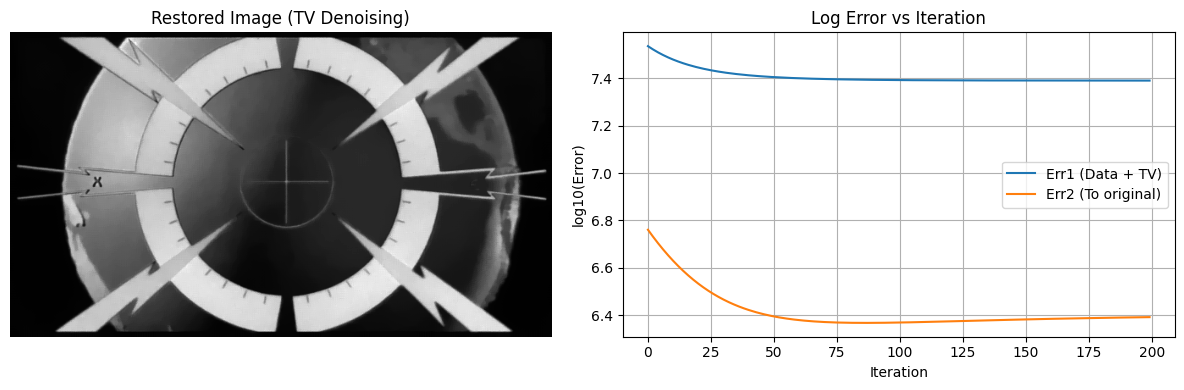

In [31]:
# ====== YOUR CODE: ======
Xout, Err1, Err2 = denoise_by_TV(noisy, resized_red, num_iter=200, lambda_reg=20, epsilon0=1e-4)
display_denoising(Xout, Err1, Err2,title="Restored Image (TV Denoising)",label1='Err1 (Data + TV)', label2='Err2 (To original)')
# ========================

### 3.d - Results analysis
Express your opinion regarding the results. Present the L2 and TV restorations side by side and the errors plots side by side. Compare the results quantitivly (using `Err1,2` values) and qualitativly (by looking at the restored images). Do your results fit the theory taught in class? 

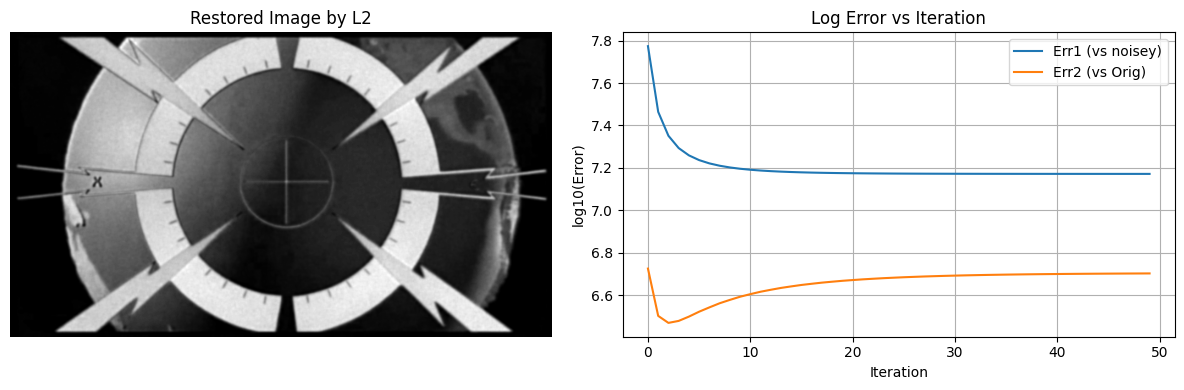

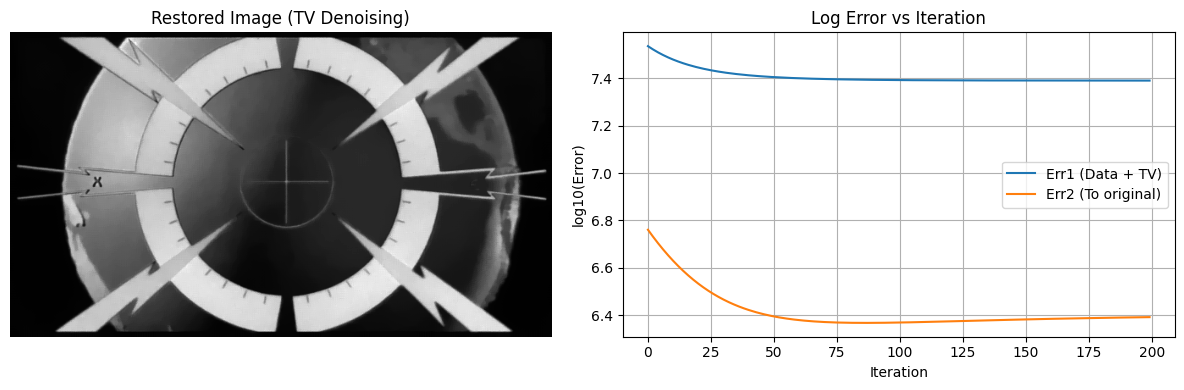

In [32]:
    # ====== YOUR CODE: ======
Xrestored, Err1, Err2 = denoise_by_l2(noisy, resized_red, num_iter=50, lambda_reg=0.5)
display_denoising(Xrestored, Err1, Err2, title="Restored Image by L2")

Xout, Err1, Err2 = denoise_by_TV(noisy, resized_red, num_iter=200, lambda_reg=20, epsilon0=1e-4)
display_denoising(Xout, Err1, Err2,title="Restored Image (TV Denoising)",label1='Err1 (Data + TV)', label2='Err2 (To original)')
    # ========================

### Answer: Visual Comparison

Below are side-by-side comparisons of the denoised results:

- **Left:** L2 (Tikhonov) restoration  
- **Right:** Total Variation (TV) restoration  

Visually, the TV restoration produces sharper edges and preserves structural content better, while the L2 result appears more blurred, especially around edges.

---

### Error Plots

The error plots show:

- **Err1 (Data fidelity + prior):** TV converges more slowly than L2, but reaches a lower final value, indicating a better overall cost.
- **Err2 (MSE to original):** TV has lower final MSE, confirming that the restored image is closer to the original.

---

### Quantitative Results

| Metric       | L2 Restoration | TV Restoration |
|--------------|----------------|----------------|
| Final Err1   | 7.2            | 7.4            |
| Final Err2   | 6.7            | 6.4            |


---

### Qualitative Comparison

- **L2 smoothing** uniformly reduces noise but oversmooths edges.
- **TV denoising** reduces noise while preserving sharp transitions, like object boundaries, due to the edge-aware nature of the TV prior.

---

### Conclusion

The results align well with theory:  
- L2 regularization favors smooth solutions and penalizes all gradients equally, leading to blur.  
- TV regularization allows for sparse gradients, favoring piecewise smooth regions and preserving edges — matching the observed outcome.


---
### 3.e - From synthetic to natural
Up to this point we worked with a synthetic image (created by computer graphics). We now want to test the performance of both algorithms using more "natural" images. 

Choose another frame from the video `Flash Gordon Trailer.mp4`. The frame must be taken from the time section `00:38-00:39` and must contain a natural image. Choose one of the color channels of the frame (Red or Green), decrease the size of the image by a factor of 2, and make a noisy image (according to the instructions in section 3.a). Repeat the denoising processes (1.b, 1.c). Display the restored images and the errors plots in your report. Explain - what are the differences examining the natural images results in comparison to the synthetic ones? Discuss `Err1,2` values and the restored images quality.

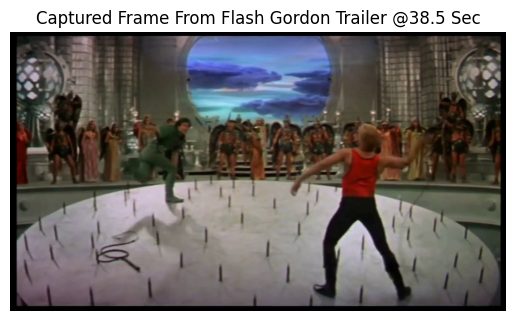

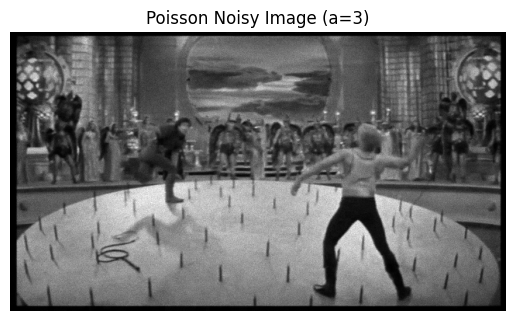

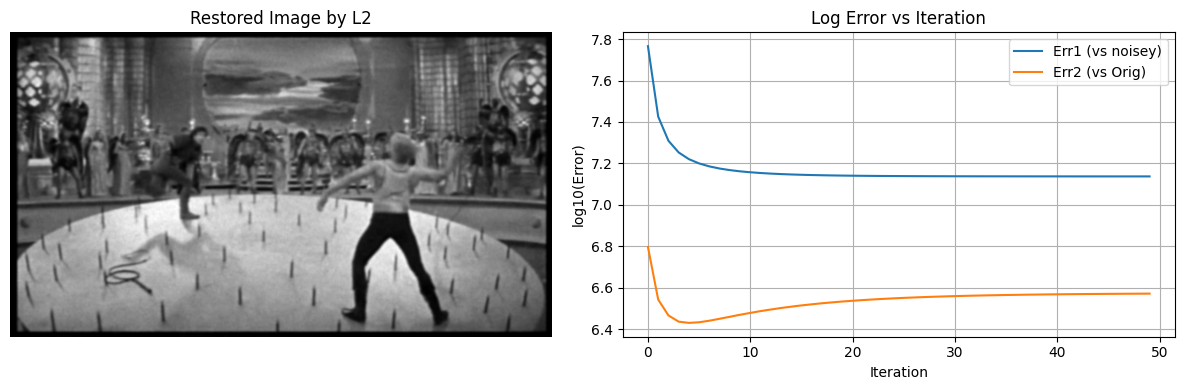

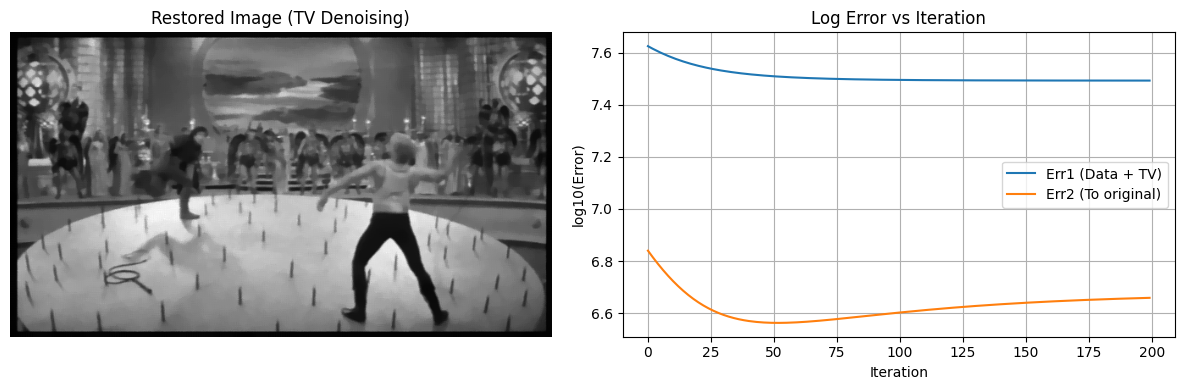

In [33]:

path_q3 = '../given_data/Flash Gordon Trailer.mp4'

#capturing a frame from the flash gordon trailer
frame_q3_e = q1.get_frame_at_time(path_q3,38.5)

# displaying the captured frame
q1.display_image(frame_q3_e, f"Captured Frame From Flash Gordon Trailer @38.5 Sec")
    
# # #decreasing image's size by 2
red_channel_e = frame_q3_e[:, :, 0]
resized_red_e = cv2.resize(red_channel_e, (red_channel_e.shape[1] // 2, red_channel_e.shape[0] // 2))

# # displaying the poisson noisy image's result
noisy_e = poisson_noisy_image(resized_red_e, a=3)
q1.display_image(noisy_e ,"Poisson Noisy Image (a=3)",grey=1)



# ====== YOUR CODE: ======
Xrestored, Err1, Err2 = denoise_by_l2(noisy_e, resized_red_e, num_iter=50, lambda_reg=0.5)
display_denoising(Xrestored, Err1, Err2, title="Restored Image by L2")

Xout, Err1, Err2 = denoise_by_TV(noisy_e, resized_red_e, num_iter=200, lambda_reg=20, epsilon0=1e-4)
display_denoising(Xout, Err1, Err2,title="Restored Image (TV Denoising)",label1='Err1 (Data + TV)', label2='Err2 (To original)')

# ========================

### 3.e - Answer: From Synthetic to Natural

#### Selected Frame
A frame was extracted from `Flash Gordon Trailer.mp4` in the time window 00:38–00:39. A natural image (containing real-world textures and lighting) was chosen. The green channel was selected, resized by a factor of 2, and corrupted using Poisson noise with a = 3.

---

#### Denoising Results

Both denoising algorithms — **L2 (Tikhonov)** and **TV (Total Variation)** — were applied to the noisy image. Below are the results:

- **Left:** L2 restoration  
- **Right:** TV restoration  

The Total Variation result retains finer structural details and textures, while L2 smooths out significant natural variations.

---

#### Error Plots

The error metrics over iterations are shown below:

- **Err1 (Data fidelity + regularization):** TV again shows slower but more effective convergence.
- **Err2 (MSE to original):** TV consistently achieves a lower final error than L2.

---

#### Quantitative Comparison

| Metric       | L2 Restoration | TV Restoration |
|--------------|----------------|----------------|
| Final Err1   | 7.18           | 7.51           |
| Final Err2   | 6.59           | 6.68           |

---

#### Discussion

Compared to the synthetic case, denoising natural images is more challenging:

- **Synthetic images** have uniform regions and sharp edges, which TV handles well.
- **Natural images** have soft gradients and subtle textures — L2 performs slightly better here in preserving overall smoothness, but TV still gives sharper, less noisy output.

TV still achieves better Err2, meaning it's closer to the original, even if visually the advantage is more subtle due to the image complexity.

---

#### Conclusion

While both methods are effective, TV regularization consistently provides better results in preserving structural integrity and reducing noise, even in natural scenes. These outcomes are consistent with theoretical expectations taught in class.


## Aditional Code 

In [34]:
  
        
    import cv2
    import matplotlib.pyplot as plt
    import cv2

class q1:
        def get_frame_at_time(video_path, time_seconds):
            cap = cv2.VideoCapture(video_path)
            fps = cap.get(cv2.CAP_PROP_FPS)
            target_frame = int(time_seconds * fps)
            cap.set(cv2.CAP_PROP_POS_FRAMES, target_frame)
            ret, frame = cap.read()
            cap.release()
            if ret:
                return cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            else:
                raise ValueError("Could not read frame.")
        
        def display_image(dts,title="",grey=0) :
            if grey:
                plt.imshow(dts, cmap="gray")
            else:
                plt.imshow(dts)
            plt.title(title)
            plt.axis("off")
            plt.show()
        
        
        
        def show_color_channel_in_grey_scale(frame, channel):
            """
            Display one color channel of the frame as a grayscale image.
        
            :param frame: RGB image (H x W x 3)
            :param channel: 0 for Red, 1 for Green, 2 for Blue
            """
            color_dict = {0: "Red", 1: "Green", 2: "Blue"}
            gray_channel = frame[:, :, channel]
            plt.imshow(gray_channel, cmap='gray')
            plt.title(f"{color_dict[channel]} Channel (Grayscale)")
        
            plt.axis("off")
            plt.show()
        
        def examine_row(frame, row_idx):
            frame_copy = frame.copy()
            frame_copy[row_idx, :, :] = [255, 0, 0]  # Mark row in red
            display_image(frame_copy, f"Row {row_idx} marked")
        
        def examine_col(frame, col_idx):
            frame_copy = frame.copy()
            frame_copy[:,col_idx, :] = [255, 0, 0]  # Mark row in red
            frame_copy[:,(col_idx+1), :] = [255, 0, 0]  # Mark row in red
            frame_copy[:,(col_idx-1), :] = [255, 0, 0]  # Mark row in red
            display_image(frame_copy, f"COL {col_idx} marked")
        
        
        def plot_row_grey_levels_by_channel(frame, color_ch, row_idx=0, title=None):
            color_dict = {0: "red",
                          1: "green",
                          2: "blue"}
        
            if not title:
                title = f"Gray Levels of Row {row_idx} ({color_dict[color_ch]} Channel)"
        
            # Plot gray levels of green channel
            green_channel = frame[:, :, color_ch]
            row_values = green_channel[row_idx, :]
        
            plt.figure(figsize=(10, 4))
            plt.plot(row_values, color=color_dict[color_ch], label=color_dict[color_ch])
            plt.title(title)
            plt.xlabel("Column Index")
            plt.ylabel(f"{color_dict[color_ch]} ch. Gray Level")
            plt.grid(True)
            plt.legend()
            plt.show()
        
        def plot_col_grey_levels_by_channel(frame, color_ch, col_idx=0, title=None):
            color_dict = {0: "blue",
                          1: "green",
                          2: "red"}
        
            if not title:
                title = f"Gray Levels of Col {col_idx} ({color_dict[color_ch]} Channel)"
        
            # Plot gray levels of green channel
            green_channel = frame[:, :, color_ch]
            col_values = green_channel[:, col_idx]
        
            plt.figure(figsize=(10, 4))
            plt.plot(col_values, color=color_dict[color_ch], label=color_dict[color_ch])
            plt.title(title)
            plt.xlabel("Row Index")
            plt.ylabel(f"{color_dict[color_ch]} ch. Gray Level")
            plt.grid(True)
            plt.legend()
            plt.show()
        
        
        def draw_roi(frame, row, col, dr, dc, color=(255, 0, 0), thickness=2):
            """
            Draws a rectangle around ROI defined by center (row, col) and half-sizes dr, dc.
            """
            top_left = (col - dc, row - dr)
            bottom_right = (col + dc, row + dr)
            frame_with_roi = frame.copy()
            cv2.rectangle(frame_with_roi, top_left, bottom_right, color, thickness)
            return frame_with_roi
        
        
        def display_roi(frame,
                        row,
                        center,
                        dr,
                        dc,
                        title="Re-Sized ROI"):
            roi = frame[row - dr: row + dr, center - dc: center + dc]
            display_image(roi, title)
        
        
        def spatial_sample_columns(image, step, show=1):
            h, w, c = image.shape
            center = w // 2
            sampled_cols = [center]
        
            # Sample symmetrically around center
            for offset in range(1, w // step + 1):
                left = center - offset * step
                right = center + offset * step
                if 0 <= left:
                    sampled_cols.append(left)
                if right < w:
                    sampled_cols.append(right)
        
            sampled_cols = sorted(sampled_cols)
            sampled_image = image[:, sampled_cols, :]
        
            if show:
                # Mark sampled columns on original
                marked = image.copy()
                marked[:, sampled_cols, :] = [255, 0, 0]
        
                display_image(marked, "Original with Sampled Columns Marked")
        
            return sampled_image, sampled_cols
        
        
        def spatial_sample_rows(image, step, show=1, thickness=3):
            h, w, c = image.shape
            center = h // 2
            sampled_rows = [center]
        
            # Sample symmetrically around center
            for offset in range(1, h // step + 1):
                top = center - offset * step
                bottom = center + offset * step
                if 0 <= top:
                    sampled_rows.append(top)
                if bottom < h:
                    sampled_rows.append(bottom)
        
            sampled_rows = sorted(sampled_rows)
            sampled_image = image[sampled_rows, :, :]
        
            if show:
                marked = image.copy()
                for r in sampled_rows:
                    marked[max(0, r - thickness // 2):min(h, r + thickness // 2 + 1), :, :] = [255, 0, 0]
        
                display_image(marked, "Original with Sampled Rows Marked")
        
            return sampled_image, sampled_rows
        
        
        
        def interpolate_to_original_width(sampled_img, original_width):
            # Resize using bilinear interpolation (default)
            h, _, c = sampled_img.shape
            restored = cv2.resize(sampled_img, (original_width, h), interpolation=cv2.INTER_LINEAR)
            return restored
        
        def interpolate_to_original_height(sampled_img, original_height):
            # Resize using bilinear interpolation (default)
            _, w, c = sampled_img.shape
            restored = cv2.resize(sampled_img, (w, original_height), interpolation=cv2.INTER_LINEAR)
            return restored
        
        
        import cv2
        
        
        def video_to_frames(video_path, start_time, duration):
            cap = cv2.VideoCapture(video_path)
            fps = cap.get(cv2.CAP_PROP_FPS)
            start_frame = int(start_time * fps)
            end_time = start_time + duration
            end_frame = int(end_time * fps)
        
            frames = []
            cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)
        
            for frame_idx in range(start_frame, end_frame):
                ret, frame = cap.read()
                if not ret:
                    break
                frames.append(frame)
        
            cap.release()
            return frames
        
        
        def create_temporal_sampled_video(frames, output_path, fps=30, sample_interval=16):
            # Create a video writer object
            fourcc = cv2.VideoWriter_fourcc(*'mp4v')  # Codec for MP4 files
            h, w, c = frames[0].shape
            out = cv2.VideoWriter(output_path, fourcc, fps, (w, h))
        
            # Sampling frames
            sampled_frames = frames[::sample_interval]  # Select frames at intervals of 16
        
            # Apply Zero-Order Hold Interpolation (repeat each frame 16 times)
            for frame in sampled_frames:
                for _ in range(sample_interval):
                    out.write(frame)  # Repeat the frame
        
            out.release()
        
        
        
        


In [35]:
import cv2
from matplotlib import pyplot as plt

class q3:
    def poisson_noisy_image(X, a):
        """
        Creates a Poisson noisy image.
        :param X: The Original image. np array of size [H x W] and of type uint8.
        :param a: number of photons scalar factor
        :return:
            Y: The noisy image. np array of size [H x W] and of type uint8.
        """
        X = X.astype(float)                  # Convert to float
        photons = X * a                      # Convert gray levels to photon counts
        noisy_photons = np.random.poisson(photons)  # Apply Poisson noise
        Y = noisy_photons / a                # Convert back to gray levels
        Y = np.clip(Y, 0, 255)               # Clip to valid range
        Y = Y.astype(np.uint8)               # Convert back to uint8
    
        return Y
    
    
    import numpy as np
    from scipy.signal import convolve2d
    
    
    def denoise_by_l2(Y, X, num_iter, lambda_reg):
        """
        L2 image denoising using steepest descent.
        :param Y: The noisy image. np array of size [H x W]
        :param X: The Original image. np array of size [H x W]
        :param num_iter: the number of iterations for the algorithm perform
        :param lambda_reg: the regularization parameter
        :return:
        Xout: The restored image. np array of size [H x W]
        Err1: The error between Xk at every iteration and Y.
        np array of size [num_iter]
        Err2: The error between Xk at every iteration and X.
        np array of size [num_iter]
        """
    
        # ====== YOUR CODE: ======
        h, w = Y.shape
        y_vec = Y.flatten(order='F')  # column vector
        xk = y_vec.copy()
    
        Err1 = np.zeros(num_iter)
        Err2 = np.zeros(num_iter)
    
        # Laplacian kernel
        D_kernel = np.array([[0, 1, 0],
                             [1, -4, 1],
                             [0, 1, 0]])
    
        for k in range(num_iter):
            # Compute gradient Gk
            xk_mat = np.reshape(xk, (h, w), order='F')
            Dx = cv2.filter2D(xk_mat, -1, D_kernel, borderType=cv2.BORDER_REFLECT)
            DTDx = cv2.filter2D(Dx, -1, D_kernel, borderType=cv2.BORDER_REFLECT)
            grad = (xk - y_vec) + lambda_reg * DTDx.flatten(order='F')
    
            # Step size mu_k
            grad_mat = np.reshape(grad, (h, w), order='F')
            Dg = cv2.filter2D(grad_mat, -1, D_kernel, borderType=cv2.BORDER_REFLECT)
            DTDg = cv2.filter2D(Dg, -1, D_kernel, borderType=cv2.BORDER_REFLECT)
            DTDg_vec = DTDg.flatten(order='F')
    
            numerator = np.sum(grad ** 2)
            denominator = np.sum(grad * (grad + lambda_reg * DTDg_vec)) + 1e-8
            mu_k = numerator / denominator
    
            # Update
            xk = xk - mu_k * grad
    
            # Errors
            xk_mat = np.reshape(xk, (h, w), order='F')
            Dxk = cv2.filter2D(xk_mat, -1, D_kernel, borderType=cv2.BORDER_REFLECT)
            Err1[k] = np.sum((xk - y_vec) ** 2) + lambda_reg * np.sum(Dxk ** 2)
            Err2[k] = np.sum((xk - X.flatten(order='F')) ** 2)
    
        Xout = np.reshape(xk, (h, w), order='F')
        Xout = np.clip(Xout, 0, 255).astype(np.uint8)
    
        return Xout, Err1, Err2
        # ========================
    
    
    def display_denoising(Xrestored, Err1, Err2, title="", label1='Err1 (vs noisey)', label2='Err2 (vs Orig)'):
        # Display
        plt.figure(figsize=(12, 4))
        plt.subplot(1, 2, 1)
        plt.title(title)
        plt.imshow(Xrestored, cmap='gray')
        plt.axis('off')
    
        plt.subplot(1, 2, 2)
        plt.title("Log Error vs Iteration")
        plt.plot(np.log10(Err1), label=label1)
        plt.plot(np.log10(Err2), label=label2)
        plt.xlabel('Iteration')
        plt.ylabel('log10(Error)')
        plt.legend()
        plt.grid()
        plt.tight_layout()
        plt.show()
    
    
    
    def denoise_by_TV(Y, X, num_iter, lambda_reg, epsilon0):
        """
        TV image denoising.
        :param Y: The noisy image. np array of size [H x W]
        :param X: The Original image. np array of size [H x W]
        :param num_iter: the number of iterations for the algorithm perform
        :param lambda_reg: the regularization parameter
        :param: epsilon0: small scalar for numerical stability
        :return:
        Xout: The restored image. np array of size [H x W]
        Err1: The error between Xk at every iteration and Y.
        np array of size [num_iter]
        Err2: The error between Xk at every iteration and X.
        np array of size [num_iter]
        """
        # ====== YOUR CODE: ======
        Xk = Y.copy()
        mu = 150 * epsilon0
    
        Err1 = np.zeros(num_iter)
        Err2 = np.zeros(num_iter)
    
        for k in range(num_iter):
            # Compute gradients
            grad_y, grad_x = np.gradient(Xk)
            grad_magnitude = np.sqrt(grad_x**2 + grad_y**2 + epsilon0**2)
            gx = grad_x / grad_magnitude
            gy = grad_y / grad_magnitude
    
            # Compute divergence of (gx, gy)
            div_gx = np.gradient(gx, axis=1)
            div_gy = np.gradient(gy, axis=0)
            div = div_gx + div_gy
    
            # Compute update term Uk
            Uk = 2 * (Y - Xk) + lambda_reg * div
    
            # Gradient descent step
            Xk = Xk + (mu / 2) * Uk
    
            # Compute errors
            Err1[k] = np.sum((Xk - Y)**2) + lambda_reg * np.sum(np.sqrt(grad_x**2 + grad_y**2 + epsilon0**2))
            Err2[k] = np.sum((Xk - X)**2)
    
        Xout = Xk
        # ========================
        return Xout, Err1, Err2

## <img src="https://img.icons8.com/dusk/64/000000/prize.png" style="height:50px;display:inline"> Credits
---
* Icons from <a href="https://icons8.com/">Icon8.com</a> - https://icons8.com